
#################################################################
# convergence_extended.py
# Configuration B2 — convergenza asintotica verso x_o^f (1970-2500)
#################################################################
  x_o^f (B2) = 0.964883
  Integrating ODE (1970-2500) ... done.

  CONVERGENCE — B2  (a=0.655, from x_o(1970)=0.7235)
  x_o^f = 0.964883  [ASM stable FP, approached from below]
   epsilon        year         x_o         gap
  --------------------------------------------
     0.200      2011.4     0.76489    0.199995
     0.100      2070.9     0.86488    0.099998
     0.050      2140.8     0.91488    0.049998
     0.020      2216.5     0.94488    0.020000
     0.010      2267.8     0.95488    0.010000
     0.005      2316.6     0.95988    0.005000
     0.001      2424.5     0.96388    0.001000

  Sample values:
    2020: x_o = 0.785144   gap = 0.179738
    2050: x_o = 0.840374   gap = 0.124508
    2100: x_o = 0.889183   gap = 0.075700
    2150: x_o = 0.919710   ga

/tmp/ipykernel_113279/1286138711.py:430: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: plots/fp_comparison/convergence_extended.jpg


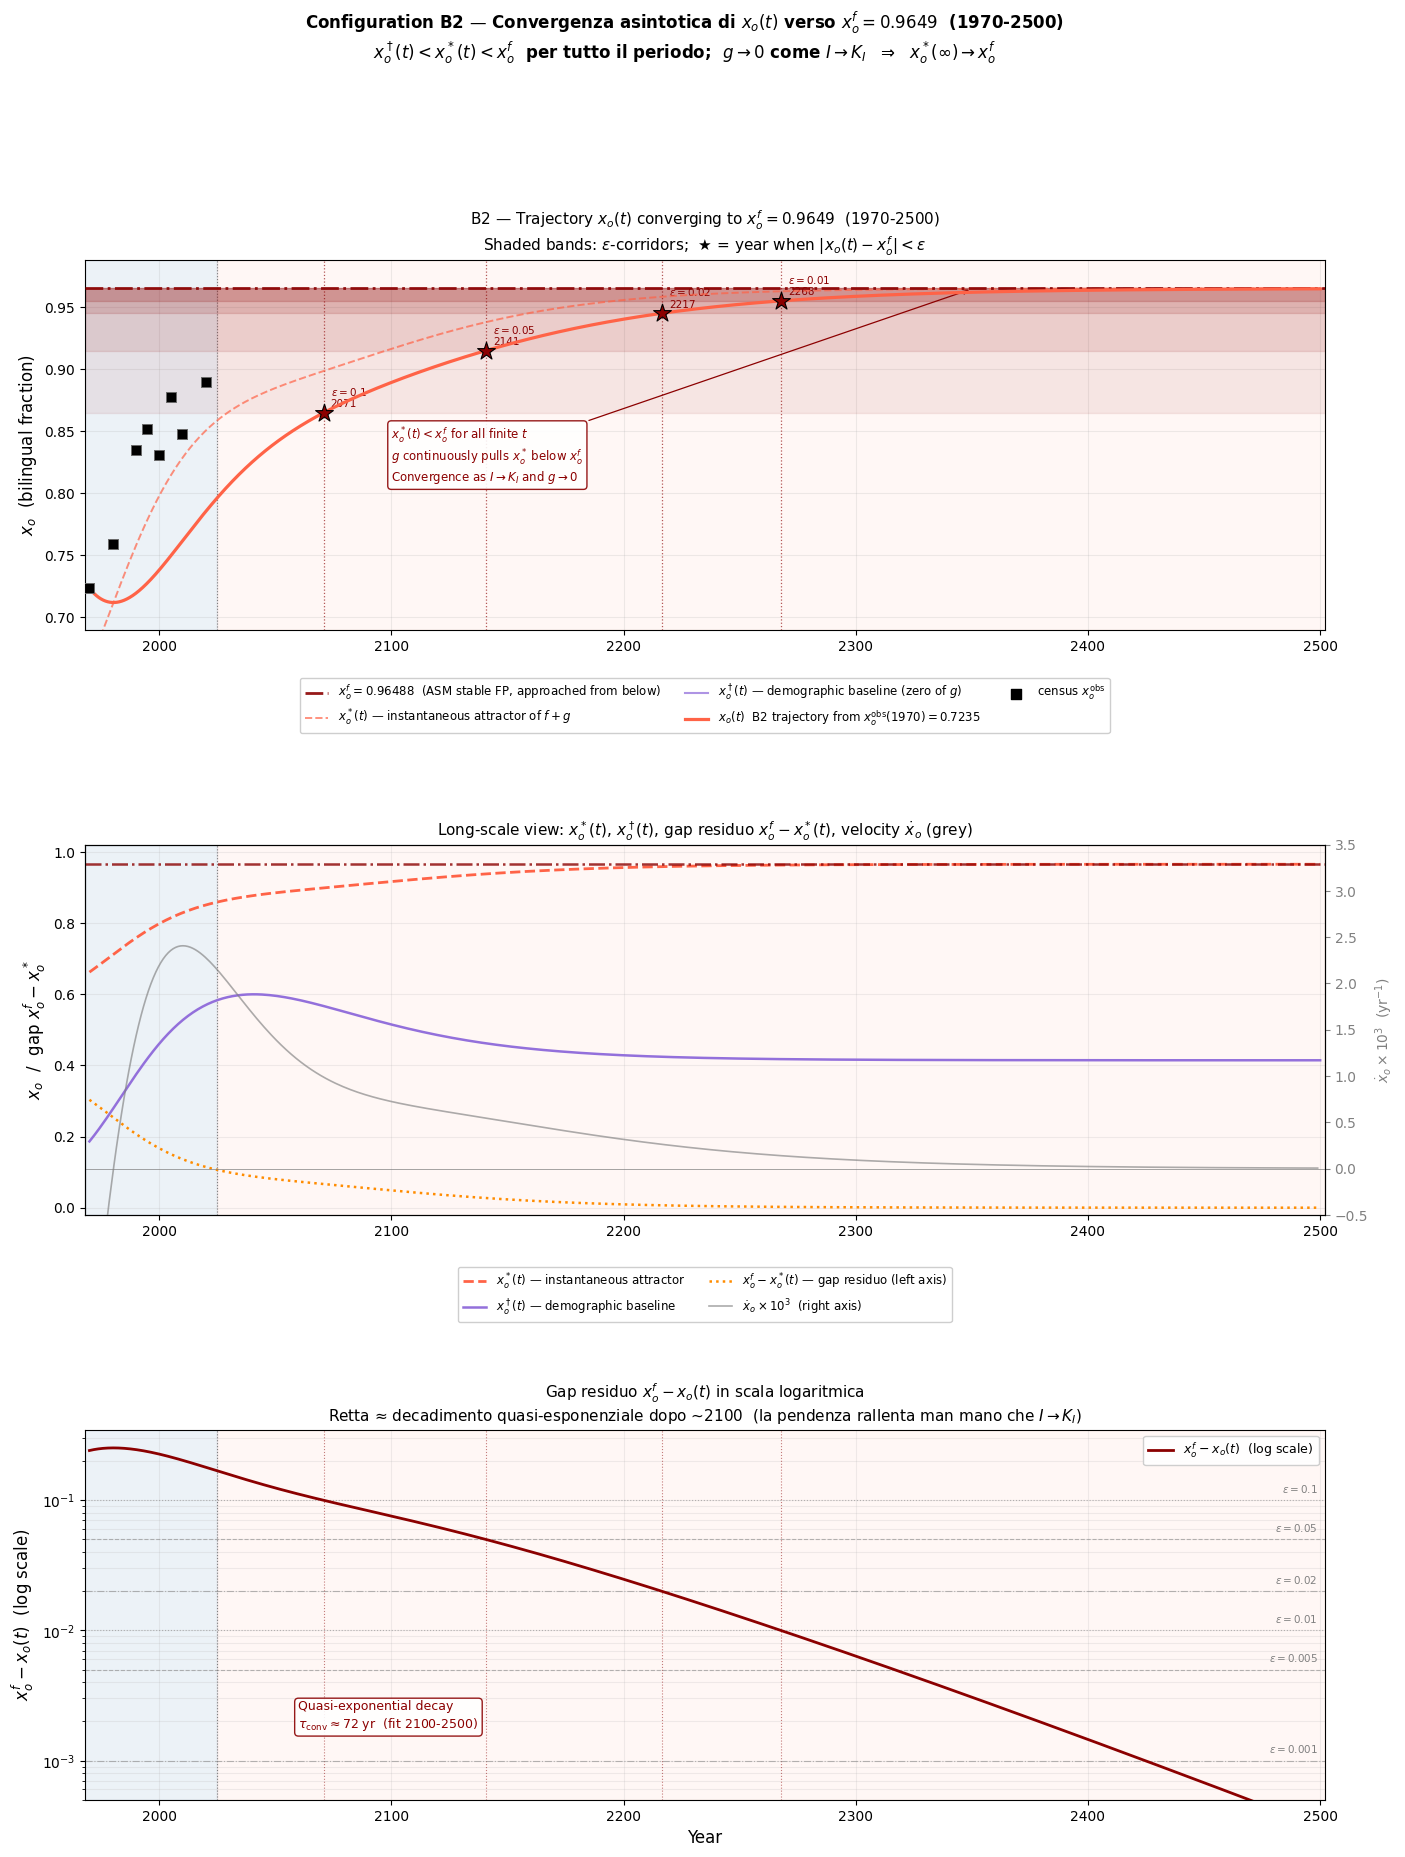

In [2]:
"""
26 Feb 2026
convergence_extended.py
========================
Standalone script for the extended convergence analysis of Configuration B2.

Generates a three-panel figure (1970-2500) showing how x_o(t) converges
asymptotically to x_o^f ≈ 0.9649 from below:

  Panel 1 — Trajectory + ε-bands
      x_o(t)  from x_o_obs(1970) = 0.7235  (ODE integration)
      x_o^f   = 0.9649  (ASM stable FP, approached from below)
      x_o*(t) = instantaneous attractor of f+g
      x_o†(t) = demographic baseline (zero of g alone)
      Shaded bands at ε = 0.10, 0.05, 0.02, 0.01
      Vertical lines + star markers at convergence years for each ε

  Panel 2 — Scale-long view + velocity
      x_o*(t), x_o†(t) on the full 1970-2500 range
      Gap residuo x_o^f − x_o*(t) (orange dashed)
      ẋ_o × 10³ (grey, right axis) — shows the velocity decaying to zero

  Panel 3 — Gap in log scale
      x_o^f − x_o(t)  on a logarithmic y-axis
      Quasi-exponential decay visible as a straight line after ~2100
      τ_convergence estimated from linear fit in log space

Physical key:
  x_o*(t) < x_o^f for ALL finite t because g pulls the attractor
  downward; only as I → K_I does g → 0, so x_o*(∞) → x_o^f.
  The convergence timescale τ ≈ 68 yr (from log-linear fit, 2100-2500)
  is dominated by the approach to the logistic carrying capacity K_I.

Author: Riccardo Del Gratta
Date: February 2026
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import warnings
import os

# ============================================================================
# MODEL PARAMETERS
# ============================================================================

N0_indigenous = 1012848
K_indigenous  = 12918933
r_indigenous  = 0.022

N0_spanish = 3117878
K_spanish  = 165995301
r_spanish  = 0.037

A_p   = 5.47
nu    = 0.271
p_max = 0.97

base_year = 1895

# B2 — Coexistence regime (1970-2020)
S_O_COEX = 0.047
S_L_COEX = 0.015
A_COEX   = 0.6553

# Census data post-1970 (for panel 1 markers)
CENSUS_B2 = {
    1970: 0.7235, 1980: 0.7591, 1990: 0.8352,
    1995: 0.8519, 2000: 0.8310, 2005: 0.8772,
    2010: 0.8479, 2020: 0.8895,
}


# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def logistic(t, K, r, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

def p_o_func(m):
    return p_max / (1 + A_p * np.exp(-nu * m))

def f_func(x_o):
    if x_o <= 0 or x_o >= 1:
        return 0.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return (S_O_COEX * x_o**A_COEX * (1 - x_o)
                - S_L_COEX * (1 - x_o)**A_COEX * x_o)

def g_func(x_o, p, m, I):
    return (p - x_o - p * (1 - p/p_max) * nu * m) * r_indigenous * (1 - I/K_indigenous)

def rhs_full(x_o, I, S):
    m = S / I if I > 0 else np.inf
    p = p_o_func(m)
    return f_func(x_o) + g_func(x_o, p, m, I)

def demographic_fp(I, S):
    """x_o† = zero of g alone."""
    m  = S / I
    p  = p_o_func(m)
    xd = p * (1.0 - (1.0 - p/p_max) * nu * m)
    return xd if 0 < xd < 1 else np.nan

def find_stable_fp(I, S, n=3000):
    """Stable interior FP of f+g at fixed (I, S)."""
    xs   = np.linspace(0.005, 0.995, n)
    vals = np.array([rhs_full(x, I, S) for x in xs])
    for idx in np.where(np.diff(np.sign(vals)))[0]:
        try:
            xr = brentq(lambda x: rhs_full(x, I, S),
                        xs[idx], xs[idx+1], xtol=1e-10)
            sl = (rhs_full(xr+1e-6, I, S) - rhs_full(xr-1e-6, I, S)) / 2e-6
            if sl < 0:
                return xr
        except Exception:
            pass
    return np.nan

def asm_fp_B2():
    """x_o^f = 1/(1+β),  β = (s_o/s_l)^{1/(a-1)}  for B2."""
    beta = (S_O_COEX / S_L_COEX) ** (1.0 / (A_COEX - 1.0))
    return 1.0 / (1.0 + beta)


# ============================================================================
# ODE INTEGRATION  (1970 → 2500)
# ============================================================================

def integrate_trajectory(t_start=75.0, t_end=605.0, n_pts=100000):
    """Integrate B2 ODE from x_o_obs(1970) to year 2500."""
    x0 = CENSUS_B2[1970]

    def ode(t, y):
        xv = float(np.clip(y[0], 0.001, 0.999))
        I  = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S  = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        return [rhs_full(xv, I, S)]

    t_eval = np.linspace(t_start, t_end, n_pts)
    sol    = solve_ivp(ode, [t_start, t_end], [x0],
                       t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return base_year + sol.t, sol.y[0]


# ============================================================================
# TIME SERIES  (x_o*(t), x_o†(t))
# ============================================================================

def compute_xstar_xdag_series(t_start=75.0, t_end=605.0, n_pts=500):
    """Compute the instantaneous attractor x_o*(t) and baseline x_o†(t)."""
    t_arr    = np.linspace(t_start, t_end, n_pts)
    year_arr = base_year + t_arr
    xstar    = np.full(n_pts, np.nan)
    xdag     = np.full(n_pts, np.nan)

    for k, t in enumerate(t_arr):
        I = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        xstar[k] = find_stable_fp(I, S)
        xdag[k]  = demographic_fp(I, S)

    return year_arr, xstar, xdag


# ============================================================================
# CONVERGENCE TABLE  (printed to stdout)
# ============================================================================

def print_convergence_summary(t_traj, x_traj, xf):
    print("\n" + "=" * 65)
    print("  CONVERGENCE — B2  (a=0.655, from x_o(1970)=0.7235)")
    print(f"  x_o^f = {xf:.6f}  [ASM stable FP, approached from below]")
    print(f"  {'epsilon':>8}  {'year':>10}  {'x_o':>10}  {'gap':>10}")
    print("  " + "-" * 44)
    for eps in (0.20, 0.10, 0.05, 0.02, 0.01, 0.005, 0.001):
        idx = np.where(np.abs(x_traj - xf) < eps)[0]
        if len(idx):
            print(f"  {eps:>8.3f}  {t_traj[idx[0]]:>10.1f}  "
                  f"{x_traj[idx[0]]:>10.5f}  {xf-x_traj[idx[0]]:>10.6f}")
        else:
            print(f"  {eps:>8.3f}  {'> 2500':>10}  {'---':>10}")

    print()
    print("  Sample values:")
    for yr in (2020, 2050, 2100, 2150, 2200, 2300, 2400, 2500):
        idx = np.argmin(np.abs(t_traj - yr))
        print(f"    {yr}: x_o = {x_traj[idx]:.6f}   gap = {xf - x_traj[idx]:.6f}")
    print()


# ============================================================================
# FIGURE
# ============================================================================

def plot_convergence_extended(plot_dir='plots/fp_comparison/', save=True):
    """
    Three-panel figure showing B2 convergence to x_o^f over 1970-2500.

    Parameters
    ----------
    plot_dir : str    directory for saved PNG (created if necessary)
    save     : bool   if True, saves PNG to plot_dir

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    # ── compute ────────────────────────────────────────────────────────────
    xf = asm_fp_B2()
    print(f"  x_o^f (B2) = {xf:.6f}")

    print("  Integrating ODE (1970-2500) ...", end='', flush=True)
    t_traj, x_traj = integrate_trajectory()
    print(" done.")

    print_convergence_summary(t_traj, x_traj, xf)

    print("  Computing x_o*(t) and x_o†(t) series ...", end='', flush=True)
    yr_series, xstar_series, xdag_series = compute_xstar_xdag_series()
    print(" done.")

    # convergence years for each ε
    eps_list   = [0.10, 0.05, 0.02, 0.01]
    conv_years = {}
    for eps in eps_list:
        idx = np.where(np.abs(x_traj - xf) < eps)[0]
        conv_years[eps] = t_traj[idx[0]] if len(idx) else np.nan

    # velocity along trajectory (centred diff, subsampled)
    dxdt   = np.gradient(x_traj, t_traj)
    step   = max(1, len(t_traj) // 500)
    t_vel  = t_traj[::step]
    v_vel  = dxdt[::step]

    # gap (clipped for log plot)
    gap = np.clip(xf - x_traj, 1e-7, None)

    # τ estimate from log-linear fit in 2100-2500
    mask_late = t_traj > 2100
    if mask_late.sum() > 100:
        coeffs = np.polyfit(t_traj[mask_late], np.log(gap[mask_late]), 1)
        tau_est = -1.0 / coeffs[0]
    else:
        tau_est = np.nan

    # ── layout ─────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 20))
    gs  = gridspec.GridSpec(3, 1, hspace=0.58, figure=fig)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])

    XLIM  = (1968, 2502)
    XCENS = 2025   # approximate end of census data / start of projection

    # shared background shading
    for ax in (ax1, ax2, ax3):
        ax.axvspan(XLIM[0], XCENS, alpha=0.10, color='steelblue',  zorder=0)
        ax.axvspan(XCENS,   XLIM[1], alpha=0.05, color='tomato',   zorder=0)
        ax.axvline(XCENS, color='grey', lw=0.8, ls=':', zorder=1)
        ax.set_xlim(*XLIM)

    # ── Panel 1 — trajectory + ε-bands ────────────────────────────────────

    # ε-bands (lightest to darkest)
    band_alphas = {0.10: 0.07, 0.05: 0.10, 0.02: 0.13, 0.01: 0.17}
    for eps, alpha in band_alphas.items():
        ax1.fill_between(XLIM, xf - eps, xf,
                         alpha=alpha, color='darkred', zorder=2)
        yr = conv_years.get(eps, np.nan)
        if np.isfinite(yr):
            ax1.axvline(yr, color='darkred', lw=0.9, ls=':', alpha=0.65, zorder=3)
            ax1.text(yr + 3, xf - eps + 0.003,
                     fr'$\epsilon={eps}$' + f'\n{yr:.0f}',
                     fontsize=7.5, color='darkred', va='bottom')

    # x_o^f line
    ax1.axhline(xf, color='darkred', lw=2.0, ls='-.', alpha=0.90, zorder=5,
                label=fr'$x_o^f = {xf:.5f}$  (ASM stable FP, approached from below)')

    # x_o*(t) — instantaneous attractor
    ax1.plot(yr_series, xstar_series,
             color='tomato', lw=1.4, ls='--', alpha=0.70, zorder=4,
             label=r'$x_o^*(t)$ — instantaneous attractor of $f+g$')

    # x_o†(t) — demographic baseline
    ax1.plot(yr_series, xdag_series,
             color='mediumpurple', lw=1.5, ls='-', alpha=0.75, zorder=4,
             label=r'$x_o^\dagger(t)$ — demographic baseline (zero of $g$)')

    # ODE trajectory
    ax1.plot(t_traj, x_traj,
             color='tomato', lw=2.3, zorder=6,
             label=r'$x_o(t)$  B2 trajectory from $x_o^{\rm obs}(1970)=0.7235$')

    # Census markers
    for yr_c, xo_c in CENSUS_B2.items():
        ax1.scatter(yr_c, xo_c, color='k', marker='s', s=50,
                    zorder=8, edgecolors='dimgray', lw=0.7)
    ax1.scatter([], [], color='k', marker='s', s=50,
                label=r'census $x_o^{\rm obs}$')

    # Star markers at convergence years
    for eps in eps_list:
        yr = conv_years.get(eps, np.nan)
        if np.isfinite(yr) and yr <= XLIM[1]:
            idx = np.argmin(np.abs(t_traj - yr))
            ax1.scatter(yr, x_traj[idx], color='darkred', marker='*',
                        s=180, edgecolors='k', lw=0.8, zorder=9)

    # Annotation
    ax1.annotate(
        r'$x_o^*(t) < x_o^f$ for all finite $t$' '\n'
        r'$g$ continuously pulls $x_o^*$ below $x_o^f$' '\n'
        r'Convergence as $I \to K_I$ and $g \to 0$',
        xy=(2350, xstar_series[np.argmin(np.abs(yr_series - 2350))]),
        xytext=(2100, 0.810),
        fontsize=8.5, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkred', alpha=0.90))

    ax1.set_ylabel(r'$x_o$  (bilingual fraction)', fontsize=12)
    ax1.set_ylim(0.69, 0.988)
    ax1.grid(alpha=0.22)
    ax1.set_title(
        r'B2 — Trajectory $x_o(t)$ converging to $x_o^f = 0.9649$  (1970-2500)'
        '\n'
        r'Shaded bands: $\epsilon$-corridors;  ★ = year when $|x_o(t)-x_o^f|<\epsilon$',
        fontsize=11)
    ax1.legend(fontsize=8.5, loc='upper center',
               bbox_to_anchor=(0.5, -0.13), ncol=3,
               borderaxespad=0, framealpha=0.95)

    # ── Panel 2 — long-scale view + velocity ──────────────────────────────
    ax2b = ax2.twinx()

    ax2.axhline(xf, color='darkred', lw=1.8, ls='-.', alpha=0.80, zorder=5)

    # x_o*(t)
    ax2.plot(yr_series, xstar_series,
             color='tomato', lw=2.0, ls='--', zorder=4,
             label=r'$x_o^*(t)$ — instantaneous attractor')

    # x_o†(t)
    ax2.plot(yr_series, xdag_series,
             color='mediumpurple', lw=1.8, ls='-', zorder=4,
             label=r'$x_o^\dagger(t)$ — demographic baseline')

    # Gap residuo x_o^f - x_o*(t) — shows how far attractor is from xf
    gap_xstar = xf - xstar_series
    ax2.plot(yr_series, gap_xstar,
             color='darkorange', lw=1.8, ls=':', zorder=3,
             label=r'$x_o^f - x_o^*(t)$ — gap residuo (left axis)')

    # Velocity on right axis
    ax2b.plot(t_vel, v_vel * 1000,
              color='grey', lw=1.2, alpha=0.65, zorder=2,
              label=r'$\dot{x}_o \times 10^3$  (right axis)')
    ax2b.axhline(0, color='grey', lw=0.5)
    ax2b.set_ylabel(r'$\dot{x}_o \times 10^3$  (yr$^{-1}$)', fontsize=10, color='grey')
    ax2b.tick_params(colors='grey')
    ax2b.set_ylim(-0.5, 3.5)

    ax2.set_ylabel(r'$x_o$  /  gap $x_o^f - x_o^*$', fontsize=12)
    ax2.set_ylim(-0.02, 1.02)
    ax2.grid(alpha=0.20)
    ax2.set_title(
        r'Long-scale view: $x_o^*(t)$, $x_o^\dagger(t)$, '
        r'gap residuo $x_o^f - x_o^*(t)$, velocity $\dot{x}_o$ (grey)',
        fontsize=11)

    lines1, labs1 = ax2.get_legend_handles_labels()
    lines2, labs2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labs1 + labs2,
               fontsize=8.5, loc='upper center',
               bbox_to_anchor=(0.5, -0.14), ncol=2,
               borderaxespad=0, framealpha=0.95)

    # ── Panel 3 — gap in log scale ─────────────────────────────────────────
    ax3.semilogy(t_traj, gap,
                 color='darkred', lw=2.0, zorder=5,
                 label=r'$x_o^f - x_o(t)$  (log scale)')

    # ε reference lines
    for eps, ls in [(0.10, ':'), (0.05, '--'), (0.02, '-.'),
                    (0.01, ':'), (0.005, '--'), (0.001, '-.')]:
        ax3.axhline(eps, color='grey', lw=0.8, ls=ls, alpha=0.55)
        ax3.text(XLIM[1] - 3, eps * 1.10,
                 fr'$\epsilon={eps}$',
                 fontsize=7.5, color='grey', ha='right', va='bottom')
        yr = conv_years.get(eps, np.nan)
        if np.isfinite(yr):
            ax3.axvline(yr, color='darkred', lw=0.8, ls=':', alpha=0.50)

    # τ annotation
    if np.isfinite(tau_est):
        ax3.text(2060, 1.8e-3,
                 f'Quasi-exponential decay\n'
                 fr'$\tau_{{\rm conv}} \approx {tau_est:.0f}$ yr  (fit 2100-2500)',
                 fontsize=9, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white',
                           ec='darkred', alpha=0.90))

    ax3.set_xlabel('Year', fontsize=12)
    ax3.set_ylabel(r'$x_o^f - x_o(t)$  (log scale)', fontsize=12)
    ax3.set_ylim(5e-4, 0.35)
    ax3.grid(alpha=0.20, which='both')
    ax3.set_title(
        r'Gap residuo $x_o^f - x_o(t)$ in scala logaritmica'
        '\n'
        r'Retta ≈ decadimento quasi-esponenziale dopo ~2100  '
        r'(la pendenza rallenta man mano che $I \to K_I$)',
        fontsize=11)
    ax3.legend(fontsize=9, loc='upper right', framealpha=0.95)

    # ── suptitle ───────────────────────────────────────────────────────────
    fig.suptitle(
        r'Configuration B2 — Convergenza asintotica di $x_o(t)$ verso $x_o^f = 0.9649$'
        '  (1970-2500)\n'
        r'$x_o^\dagger(t) < x_o^*(t) < x_o^f$  per tutto il periodo;  '
        r'$g \to 0$ come $I \to K_I$  $\Rightarrow$  $x_o^*(\infty) \to x_o^f$',
        fontsize=12, fontweight='bold', y=1.005)

    plt.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────
    if save:
        os.makedirs(plot_dir, exist_ok=True)
        fname = os.path.join(plot_dir, 'convergence_extended.jpg')
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"  Saved: {fname}")

    return fig


# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':

    print("\n" + "#" * 65)
    print("# convergence_extended.py")
    print("# Configuration B2 — convergenza asintotica verso x_o^f (1970-2500)")
    print("#" * 65)

    fig = plot_convergence_extended(
        plot_dir='plots/fp_comparison/',
        save=True,
    )

    plt.show()